# Figure 4 — Distance-band gradient

**Target**: npj Urban Sustainability submission (Helene + Milton mobility paper).

Three panels, generated as separate files for external composition (Illustrator / Inkscape / Affinity / PowerPoint):

- **(a)** Largest within-region drop vs. distance band, facetted by hurricane.
- **(b)** Trend-based recovery time vs. distance band, facetted by hurricane.
- **(c)** Map: counties coloured by **band-level** recovery time, with the hurricane track and 10 / 25 mi buffer rings overlaid. Two subpanels (Helene, Milton).

## Data sources (all pre-computed — *no analysis re-run*)

| File | Used for |
|---|---|
| `results/local_level/milton/metrics_within.csv` | Milton per-county `largest_drop`, `recovery_days` (within, total mobility) |
| `results/local_level/milton/county_distance_to_track.csv` | Milton county centroid → track distance (mi) |
| `results/local_level/milton/county_metadata.csv` | Milton GEOID ↔ name |
| `results/local_level/helene/cluster_results_within.csv` | Helene per-cluster `largest_drop`, `recovery_days`, `mean_dist_to_track`, `n_counties` |
| `results/helene_clustering/county_cluster_assignments.csv` | Helene GEOID ↔ cluster + per-county `dist_to_track_mi` |
| `tl_2023_us_county.shp`, `{helene,milton}_storm_track.shp` (sibling `hurricane_oct/data/`) | Choropleth geometry for panel (c) |

## Scope caveat

The figure plan also calls for a 6-category breakdown per band. Pre-computed local baselines are stored as **total within-region mobility per unit** — there is no per-(category × unit) baseline on disk. Producing a 3-band × 6-category matrix would require re-fitting SARIMAX for every (band × category) aggregate, which is out of scope here. This notebook therefore reports the **distance-band gradient for total within-region mobility** at the unit level (Milton: 21 counties; Helene: 38 clusters → 271 counties via cluster assignment).

## Distance bands

Three bands: **0–10 mi** (direct track), **10–25 mi** (near-track), **25+ mi** (peripheral). The plan's nominal third band of 25–50 mi would drop the ~17 units lying 50–77 mi from the track; the **25+** label keeps every affected unit in the figure while preserving the same gradient interpretation.

## Outputs

Vector PDF + 300 dpi PNG per panel in `results/npj_figures/`:

- `figure4a_drop_by_band.{pdf,png}`
- `figure4b_recovery_by_band.{pdf,png}`
- `figure4c_band_recovery_map.{pdf,png}`

In [1]:
import pathlib
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import LineString
from shapely.ops import unary_union

warnings.filterwarnings('ignore')

# npj Urban Sustainability print-ready formatting (matches figures 1–3)
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

In [2]:
# ── Project path resolution (walk up to the directory holding results/) ──
def find_project_root(start: pathlib.Path) -> pathlib.Path:
    sentinel = pathlib.Path('results') / 'regional_level' / 'regional_metrics_summary.csv'
    for p in [start, *start.parents]:
        if (p / sentinel).exists():
            return p
    raise FileNotFoundError(
        f'Could not locate project root containing {sentinel} (started from {start}).'
    )

NOTEBOOK_DIR = pathlib.Path.cwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)
RESULTS = PROJECT_ROOT / 'results'
LOCAL    = RESULTS / 'local_level'
CLUSTER  = RESULTS / 'helene_clustering'

# External geo data (sibling project; same source figure 1 uses)
HURRICANE_OCT_DATA = PROJECT_ROOT.parent / 'hurricane_oct' / 'data'
COUNTY_SHP = HURRICANE_OCT_DATA / 'county_geo' / 'tl_2023_us_county' / 'tl_2023_us_county.shp'
TRACK_SHP = {
    'helene': HURRICANE_OCT_DATA / 'storm_track' / 'helene_storm_track.shp',
    'milton': HURRICANE_OCT_DATA / 'storm_track' / 'milton_storm_track.shp',
}

OUT_DIR = RESULTS / 'npj_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'COUNTY_SHP   : exists={COUNTY_SHP.exists()}')
print(f'TRACK_SHP    : helene={TRACK_SHP["helene"].exists()}, milton={TRACK_SHP["milton"].exists()}')
print(f'OUT_DIR      : {OUT_DIR}')

PROJECT_ROOT : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category
COUNTY_SHP   : exists=True
TRACK_SHP    : helene=True, milton=True
OUT_DIR      : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures


In [3]:
# ── Configuration ──
HURRICANES = {
    'helene': {
        'label':   'Helene',
        'landing': pd.Timestamp('2024-09-26'),
        'color':   '#1f77b4',
        'fill':    '#bbd6e8',
        'unit':    'cluster',   # Helene metrics are at the cluster level
    },
    'milton': {
        'label':   'Milton',
        'landing': pd.Timestamp('2024-10-09'),
        'color':   '#d62728',
        'fill':    '#f6c0bf',
        'unit':    'county',    # Milton metrics are at the county level
    },
}

# Distance-band scheme: 0–10 / 10–25 / 25+ mi
BAND_EDGES  = [0, 10, 25, np.inf]
BAND_LABELS = ['0–10 mi', '10–25 mi', '25+ mi']
BAND_COLORS = {
    '0–10 mi':  '#d6604d',  # close — warm
    '10–25 mi': '#f4a582',
    '25+ mi':   '#92c5de',  # far — cool
}

def assign_band(dist_mi: pd.Series) -> pd.Categorical:
    """Bucket distance-to-track (mi) into the 3-band scheme."""
    return pd.cut(dist_mi, bins=BAND_EDGES, labels=BAND_LABELS,
                  include_lowest=True, right=True)

def save_panel(fig, stem):
    pdf_path = OUT_DIR / f'{stem}.pdf'
    png_path = OUT_DIR / f'{stem}.png'
    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f'  saved \u2192 {pdf_path}')
    print(f'  saved \u2192 {png_path}')

## Assemble a unit-level table per hurricane

Each row is one analysis unit (Milton county or Helene cluster) with its `largest_drop`, `recovery_days`, and `dist_to_track_mi`. Helene clusters carry `n_counties` for weighting in summary stats. The same dataframe drives panels (a) and (b).

In [4]:
def load_milton_units() -> pd.DataFrame:
    m = pd.read_csv(LOCAL / 'milton' / 'metrics_within.csv')
    d = pd.read_csv(LOCAL / 'milton' / 'county_distance_to_track.csv')
    n = pd.read_csv(LOCAL / 'milton' / 'county_metadata.csv')
    df = (m.rename(columns={'unit_id': 'GEOID'})
            .merge(d[['GEOID', 'dist_to_track_mi']], on='GEOID', how='left')
            .merge(n[['GEOID', 'NAME']],             on='GEOID', how='left'))
    df['n_counties'] = 1
    df['unit_kind']  = 'county'
    return df[['GEOID', 'NAME', 'unit_kind', 'n_counties',
               'largest_drop', 'recovery_days', 'dist_to_track_mi']]

def load_helene_units() -> pd.DataFrame:
    c = pd.read_csv(LOCAL / 'helene' / 'cluster_results_within.csv')
    df = c.rename(columns={'cluster':            'GEOID',
                            'mean_dist_to_track': 'dist_to_track_mi'}).copy()
    df['GEOID']     = df['GEOID'].astype(int).astype(str)
    df['NAME']      = 'Cluster ' + df['GEOID']
    df['unit_kind'] = 'cluster'
    return df[['GEOID', 'NAME', 'unit_kind', 'n_counties',
               'largest_drop', 'recovery_days', 'dist_to_track_mi']]

UNITS = {
    'helene': load_helene_units(),
    'milton': load_milton_units(),
}

for hkey, df in UNITS.items():
    df['band'] = assign_band(df['dist_to_track_mi'])
    print(f'{hkey}: {len(df)} units '
          f'(n_counties total = {df["n_counties"].sum()})')
    print(df.groupby('band', observed=True)
            .agg(units=('GEOID', 'count'),
                 counties=('n_counties', 'sum'),
                 drop_mean=('largest_drop', 'mean'),
                 drop_median=('largest_drop', 'median'),
                 rec_mean=('recovery_days', 'mean'),
                 rec_median=('recovery_days', 'median'))
            .round(2))
    print()

helene: 38 units (n_counties total = 271)
          units  counties  drop_mean  drop_median  rec_mean  rec_median
band                                                                   
0–10 mi       2         4     -17.82       -17.82     18.00        18.0
10–25 mi      7        52     -12.73       -11.68      3.71         4.0
25+ mi       29       215     -17.60       -16.22      4.57         4.0

milton: 21 units (n_counties total = 21)
          units  counties  drop_mean  drop_median  rec_mean  rec_median
band                                                                   
0–10 mi       2         2     -32.05       -32.05      4.44        4.44
10–25 mi      6         6     -29.32       -27.40      4.74        4.74
25+ mi       13        13     -33.25       -32.93      4.47        4.47



## Panel (a) — Largest within-region drop vs. distance band

Per-unit drops shown as strip points, with a box for the within-band distribution; one subpanel per hurricane. The boxes summarise the median ± IQR per band — read as: *closer-to-track bands tend to have deeper drops*.

Saves `figure4a_drop_by_band.{pdf,png}`.

  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure4a_drop_by_band.pdf
  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure4a_drop_by_band.png


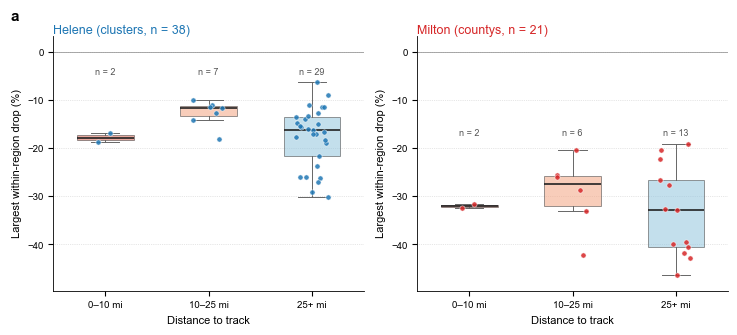

In [5]:
def _strip_box(ax, df, value_col, ylabel, title, color, jitter=0.16, seed=0):
    """Strip + box overlay across the 3 distance bands."""
    rng = np.random.default_rng(seed)
    positions = np.arange(len(BAND_LABELS))

    grouped = [df.loc[df['band'] == b, value_col].dropna().values
               for b in BAND_LABELS]

    bp = ax.boxplot(grouped, positions=positions, widths=0.55,
                    showfliers=False, patch_artist=True,
                    medianprops=dict(color='#222', linewidth=1.2),
                    whiskerprops=dict(color='#666', linewidth=0.7),
                    capprops=dict(color='#666', linewidth=0.7),
                    boxprops=dict(linewidth=0.7))
    for patch, band in zip(bp['boxes'], BAND_LABELS):
        patch.set_facecolor(BAND_COLORS[band])
        patch.set_alpha(0.55)
        patch.set_edgecolor('#444')

    for i, vals in enumerate(grouped):
        if len(vals) == 0:
            continue
        xs = positions[i] + rng.uniform(-jitter, jitter, size=len(vals))
        ax.scatter(xs, vals, s=14, color=color, edgecolor='white',
                   linewidth=0.4, alpha=0.85, zorder=4)

    for i, vals in enumerate(grouped):
        ax.text(positions[i], ax.get_ylim()[1], f'n = {len(vals)}',
                ha='center', va='bottom', fontsize=6.5, color='#555')

    ax.set_xticks(positions)
    ax.set_xticklabels(BAND_LABELS)
    ax.set_xlabel('Distance to track')
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left', fontsize=9, color=color, pad=2)
    ax.grid(axis='y', linestyle=':', color='#bbbbbb', linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)


def panel_a_drop(axes):
    for ax, hkey in zip(axes, HURRICANES):
        h = HURRICANES[hkey]
        df = UNITS[hkey]
        _strip_box(ax, df, 'largest_drop',
                   ylabel='Largest within-region drop (%)',
                   title=f'{h["label"]} ({df["unit_kind"].iloc[0]}s, n = {len(df)})',
                   color=h['color'])
        ax.axhline(0, color='#888', linewidth=0.5, linestyle='-', zorder=1)

    ymin = min(a.get_ylim()[0] for a in axes)
    ymax = max(a.get_ylim()[1] for a in axes)
    pad  = 0.02 * (ymax - ymin)
    for a in axes:
        a.set_ylim(ymin - pad, ymax + pad)

    axes[0].text(-0.14, 1.05, 'a', transform=axes[0].transAxes,
                 fontsize=11, fontweight='bold', va='bottom', ha='left')


fig_a, axes_a = plt.subplots(1, 2, figsize=(7.4, 3.4), sharey=False)
panel_a_drop(axes_a)
fig_a.tight_layout()
save_panel(fig_a, 'figure4a_drop_by_band')
plt.show()

## Panel (b) — Recovery time vs. distance band

Same layout as panel (a) but for `recovery_days` (trend-based, Theil–Sen, measured from landing). Faster vs. slower recovery as a function of proximity to the track.

Saves `figure4b_recovery_by_band.{pdf,png}`.

  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure4b_recovery_by_band.pdf
  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure4b_recovery_by_band.png


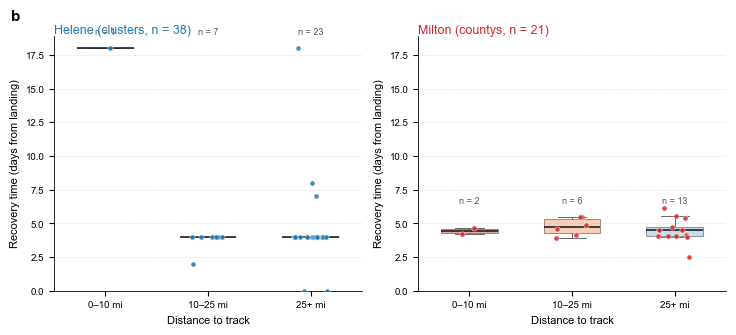

In [6]:
def panel_b_recovery(axes):
    for ax, hkey in zip(axes, HURRICANES):
        h = HURRICANES[hkey]
        df = UNITS[hkey]
        _strip_box(ax, df, 'recovery_days',
                   ylabel='Recovery time (days from landing)',
                   title=f'{h["label"]} ({df["unit_kind"].iloc[0]}s, n = {len(df)})',
                   color=h['color'])

    ymax = max(a.get_ylim()[1] for a in axes)
    for a in axes:
        a.set_ylim(0, ymax)

    axes[0].text(-0.14, 1.05, 'b', transform=axes[0].transAxes,
                 fontsize=11, fontweight='bold', va='bottom', ha='left')


fig_b, axes_b = plt.subplots(1, 2, figsize=(7.4, 3.4), sharey=False)
panel_b_recovery(axes_b)
fig_b.tight_layout()
save_panel(fig_b, 'figure4b_recovery_by_band')
plt.show()

## Band-level summary for panel (c)

Panel (c) shows counties coloured by their band's recovery time. We:
1. compute the **county-weighted mean** of `recovery_days` per band (Helene clusters get weighted by `n_counties`; Milton counties are weight 1);
2. assign every affected county its band's recovery value via the per-county distance file.

For Helene, each county gets the band of its own `dist_to_track_mi` (not its cluster's mean). This keeps the band assignment a clean function of physical proximity to the track.

In [7]:
def band_recovery_summary(hkey: str) -> pd.DataFrame:
    df = UNITS[hkey].dropna(subset=['recovery_days', 'band']).copy()
    out = (df.groupby('band', observed=True)
             .apply(lambda g: pd.Series({
                 'n_units':           len(g),
                 'n_counties':        int(g['n_counties'].sum()),
                 'recovery_mean':     np.average(g['recovery_days'],
                                                 weights=g['n_counties']),
                 'recovery_median':   g['recovery_days'].median(),
                 'drop_mean':         np.average(g['largest_drop'],
                                                  weights=g['n_counties']),
             }))
             .reindex(BAND_LABELS))
    return out

BAND_SUMMARY = {h: band_recovery_summary(h) for h in HURRICANES}
for hkey, tbl in BAND_SUMMARY.items():
    print(f'── {hkey} ──')
    print(tbl.round(2))
    print()

── helene ──
          n_units  n_counties  recovery_mean  recovery_median  drop_mean
band                                                                    
0–10 mi       1.0         3.0          18.00             18.0     -18.78
10–25 mi      7.0        52.0           3.92              4.0     -12.19
25+ mi       23.0       203.0           4.58              4.0     -12.93

── milton ──
          n_units  n_counties  recovery_mean  recovery_median  drop_mean
band                                                                    
0–10 mi       2.0         2.0           4.44             4.44     -32.05
10–25 mi      6.0         6.0           4.74             4.74     -29.32
25+ mi       13.0        13.0           4.47             4.47     -33.25



In [8]:
def county_band_recovery(hkey: str) -> pd.DataFrame:
    """Return GEOID -> (dist_to_track_mi, band, band_recovery_days) for every affected county."""
    band_rec = BAND_SUMMARY[hkey]['recovery_mean']
    if hkey == 'milton':
        d = pd.read_csv(LOCAL / 'milton' / 'county_distance_to_track.csv')
        d['GEOID'] = d['GEOID'].astype(int).astype(str).str.zfill(5)
    else:  # helene — per-county distances live in the cluster assignment file
        d = pd.read_csv(CLUSTER / 'county_cluster_assignments.csv')
        d['GEOID'] = d['GEOID'].astype(int).astype(str).str.zfill(5)
        d = d[['GEOID', 'dist_to_track_mi']]
    d['band'] = assign_band(d['dist_to_track_mi'])
    d['band_recovery_days'] = d['band'].map(band_rec)
    return d

COUNTY_BAND = {h: county_band_recovery(h) for h in HURRICANES}
for hkey, df in COUNTY_BAND.items():
    print(f'{hkey}: {len(df)} counties, '
          f'recovery range {df["band_recovery_days"].min():.2f} → '
          f'{df["band_recovery_days"].max():.2f} d')

helene: 271 counties, recovery range 18.00 → 4.58 d
milton: 21 counties, recovery range 4.44 → 4.47 d


## Panel (c) — Map of band-level recovery, both hurricanes

Two subpanels (Helene, Milton). Counties are coloured by their band's mean recovery days (weighted by counties-per-cluster for Helene). The hurricane track is drawn over the choropleth, and the 10 mi / 25 mi buffer rings make the band boundaries explicit. Counties beyond the unit set (≥50 mi cutoff for Milton, the 271-county Helene cluster set) are left grey.

Saves `figure4c_band_recovery_map.{pdf,png}`.

In [9]:
# Load the county shapefile once (~3300 US counties); subset later per hurricane.
COUNTIES_ALL = gpd.read_file(COUNTY_SHP).to_crs(epsg=5070)
COUNTIES_ALL['GEOID'] = COUNTIES_ALL['GEOID'].astype(str).str.zfill(5)
print('counties loaded:', len(COUNTIES_ALL))

# Load both tracks as single LineStrings in EPSG:5070 (metres).
def load_track(path):
    tg = gpd.read_file(path).to_crs(epsg=5070)
    geom0 = tg.geometry.iloc[0]
    if geom0.geom_type == 'Point':
        return LineString(tg.geometry.tolist())
    return unary_union(tg.geometry.tolist())

TRACKS = {h: load_track(TRACK_SHP[h]) for h in HURRICANES}

MI_TO_M = 1609.34

counties loaded: 3235


  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure4c_band_recovery_map.pdf
  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure4c_band_recovery_map.png


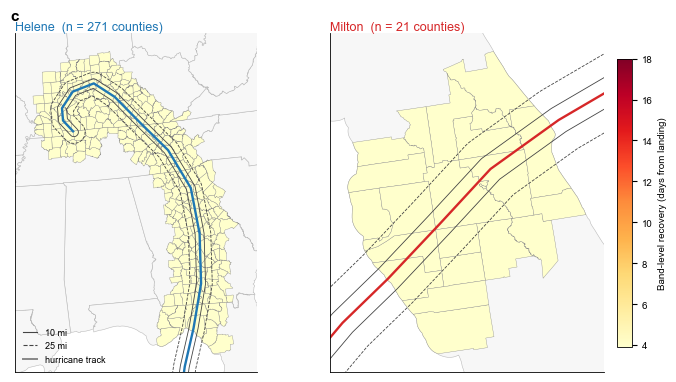

In [10]:
def panel_c_map(axes):
    # Build a shared recovery scale across both hurricanes so colours are comparable.
    all_recovery = pd.concat([
        BAND_SUMMARY[h]['recovery_mean'].dropna() for h in HURRICANES
    ])
    vmin = float(all_recovery.min())
    vmax = float(all_recovery.max())
    cmap = mpl.cm.get_cmap('YlOrRd')
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    panel_label = {0: 'c', 1: ''}

    for i, (ax, hkey) in enumerate(zip(axes, HURRICANES)):
        h = HURRICANES[hkey]
        cb = COUNTY_BAND[hkey].copy()
        cb = cb.dropna(subset=['band_recovery_days'])
        cb['GEOID'] = cb['GEOID'].astype(str).str.zfill(5)

        affected = COUNTIES_ALL.merge(cb, on='GEOID', how='inner')

        # Background: state outlines (dissolve all counties)
        states = COUNTIES_ALL.dissolve(by='STATEFP')
        states.plot(ax=ax, facecolor='#f7f7f7', edgecolor='#bbbbbb', linewidth=0.4)

        # Choropleth — counties coloured by band recovery
        affected.plot(ax=ax, column='band_recovery_days', cmap=cmap, norm=norm,
                      edgecolor='#888', linewidth=0.25)

        # 10 mi / 25 mi buffer rings around the track
        for d_mi, ls in [(10, '-'), (25, '--')]:
            ring = TRACKS[hkey].buffer(d_mi * MI_TO_M)
            gpd.GeoSeries([ring], crs='EPSG:5070').boundary.plot(
                ax=ax, color='#444', linewidth=0.6, linestyle=ls
            )

        # Track
        gpd.GeoSeries([TRACKS[hkey]], crs='EPSG:5070').plot(
            ax=ax, color=h['color'], linewidth=1.7
        )

        # Extent from affected + a small pad
        minx, miny, maxx, maxy = affected.total_bounds
        pad = 0.06 * max(maxx - minx, maxy - miny)
        ax.set_xlim(minx - pad, maxx + pad)
        ax.set_ylim(miny - pad, maxy + pad)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])

        ax.set_title(f'{h["label"]}  (n = {len(affected)} counties)',
                     loc='left', fontsize=9, color=h['color'], pad=2)
        if panel_label[i]:
            ax.text(-0.02, 1.03, panel_label[i], transform=ax.transAxes,
                    fontsize=11, fontweight='bold', va='bottom', ha='left')

    # Shared colorbar on the right
    fig = axes[0].figure
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='vertical',
                        fraction=0.025, pad=0.02, shrink=0.85)
    cbar.set_label('Band-level recovery (days from landing)', fontsize=7)
    cbar.ax.tick_params(labelsize=7)

    # Shared legend for the buffer rings + track
    legend_handles = [
        Line2D([0], [0], color='#444', linewidth=0.8, linestyle='-',  label='10 mi'),
        Line2D([0], [0], color='#444', linewidth=0.8, linestyle='--', label='25 mi'),
        Line2D([0], [0], color='#888', linewidth=1.4, linestyle='-',  label='hurricane track'),
    ]
    axes[0].legend(handles=legend_handles, loc='lower left', frameon=False, fontsize=6.5,
                   handlelength=1.6)


fig_c, axes_c = plt.subplots(1, 2, figsize=(8.6, 4.4))
panel_c_map(axes_c)
save_panel(fig_c, 'figure4c_band_recovery_map')
plt.show()

## Export the band-level table (for the supplementary or the caption)

In [11]:
summary = pd.concat({h: BAND_SUMMARY[h] for h in HURRICANES}, names=['hurricane', 'band'])
summary = summary.round(3)
out_csv = OUT_DIR / 'figure4_band_summary.csv'
summary.to_csv(out_csv)
print(f'  saved \u2192 {out_csv}')
summary

  saved → /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures/figure4_band_summary.csv


n_units  n_counties  recovery_mean  recovery_median  \
hurricane band                                                            
helene    0–10 mi       1.0         3.0         18.000           18.000   
          10–25 mi      7.0        52.0          3.923            4.000   
          25+ mi       23.0       203.0          4.581            4.000   
milton    0–10 mi       2.0         2.0          4.437            4.437   
          10–25 mi      6.0         6.0          4.744            4.743   
          25+ mi       13.0        13.0          4.472            4.472   

                    drop_mean  
hurricane band                 
helene    0–10 mi     -18.784  
          10–25 mi    -12.185  
          25+ mi      -12.928  
milton    0–10 mi     -32.052  
          10–25 mi    -29.324  
          25+ mi      -33.249

### Caption draft (for when you assemble the combined Fig. 4)

**Fig. 4 | Distance-band gradient: physical exposure shapes mobility disruption and recovery.**
Affected analysis units (Milton: 21 counties; Helene: 38 NCHS clusters covering 271 counties) are binned into three distance bands by their minimum centroid → hurricane-track distance: 0–10 mi (direct track), 10–25 mi (near-track), 25+ mi (peripheral).
**(a)** Largest within-region drop (%) per unit by band, with box (median ± IQR) overlays. Closer-to-track bands show systematically deeper troughs in both hurricanes.
**(b)** Trend-based recovery time (days from landing, Theil–Sen on the smoothed monotonic recovery segment) per unit by band.
**(c)** Choropleth of affected counties colored by their band's recovery time (counties-weighted mean), with the hurricane track and 10 / 25 mi buffer rings overlaid. The shared colour scale supports direct cross-hurricane comparison.

*Scope: panels here use within-region mobility summed across the six urban-functional categories (Utilities excluded). A per-(band × category) decomposition is deferred to a supplementary figure because the pre-computed local baselines are total-mobility only.*